In [1]:
import sys
print(sys.executable)

/Users/dipasmitadebroy/Documents/Artificial_Intelligence/ml_projects/movie-recommender/venv/bin/python


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from surprise import SVD, Dataset, Reader
from surprise.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib, os, warnings

warnings.filterwarnings("ignore")
%matplotlib inline
print("✅ Imports done")

✅ Imports done


In [3]:
PROCESSED_DIR = "../data/processed/"
MODEL_DIR     = "../models/"
FIGURES_DIR   = "../reports/figures/"

train = pd.read_parquet(PROCESSED_DIR + "train.parquet")
test  = pd.read_parquet(PROCESSED_DIR + "test.parquet")
y_true = test["rating"].values

reader   = Reader(rating_scale=(0.5, 5.0))
data_sur = Dataset.load_from_df(train[["userId", "movieId", "rating"]], reader)
trainset = data_sur.build_full_trainset()

print(f"Train: {len(train):,} | Test: {len(test):,}")

Train: 19,784,257 | Test: 5,026,226


In [4]:
svd = SVD(n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02, biased=True, verbose=True)
svd.fit(trainset)
print("✅ SVD trained")

Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 10
Processing epoch 11
Processing epoch 12
Processing epoch 13
Processing epoch 14
Processing epoch 15
Processing epoch 16
Processing epoch 17
Processing epoch 18
Processing epoch 19
✅ SVD trained


In [5]:
# Predict & Evaluate

preds_svd = np.clip(
    [svd.predict(r.userId, r.movieId).est for r in test.itertuples()], 0.5, 5.0
)

rmse_svd = np.sqrt(mean_squared_error(y_true, preds_svd))
mae_svd  = mean_absolute_error(y_true, preds_svd)

print("=" * 40)
print("📊 SVD (default params)")
print(f"   RMSE : {rmse_svd:.4f}")
print(f"   MAE  : {mae_svd:.4f}")
print("=" * 40)

📊 SVD (default params)
   RMSE : 0.7949
   MAE  : 0.5976


In [6]:
#Hyperparameter tuning 

# ⚠️ Takes ~10–20 min. Skip to Cell 6 to use defaults.

param_grid = {
    "n_factors": [50, 100],
    "n_epochs" : [20, 30],
    "lr_all"   : [0.005, 0.010],
    "reg_all"  : [0.02, 0.10],
}
gs = GridSearchCV(SVD, param_grid, measures=["rmse"], cv=3, n_jobs=-1, joblib_verbose=1)
gs.fit(data_sur)

print(f"Best RMSE  : {gs.best_score['rmse']:.4f}")
print(f"Best params: {gs.best_params['rmse']}")
best_params = gs.best_params["rmse"]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  48 out of  48 | elapsed: 478.3min finished


Best RMSE  : 0.7913
Best params: {'n_factors': 50, 'n_epochs': 30, 'lr_all': 0.005, 'reg_all': 0.02}


In [7]:
# Train tuned SVD

svd_tuned = SVD(**best_params, biased=True, verbose=True)
svd_tuned.fit(trainset)

preds_svd_tuned = np.clip(
    [svd_tuned.predict(r.userId, r.movieId).est for r in test.itertuples()], 0.5, 5.0
)

rmse_t = np.sqrt(mean_squared_error(y_true, preds_svd_tuned))
mae_t  = mean_absolute_error(y_true, preds_svd_tuned)

print(f"Tuned SVD → RMSE: {rmse_t:.4f} | MAE: {mae_t:.4f}")
svd_results = {"model": "SVD", "RMSE": rmse_t, "MAE": mae_t}

Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 10
Processing epoch 11
Processing epoch 12
Processing epoch 13
Processing epoch 14
Processing epoch 15
Processing epoch 16
Processing epoch 17
Processing epoch 18
Processing epoch 19
Processing epoch 20
Processing epoch 21
Processing epoch 22
Processing epoch 23
Processing epoch 24
Processing epoch 25
Processing epoch 26
Processing epoch 27
Processing epoch 28
Processing epoch 29
Tuned SVD → RMSE: 0.7927 | MAE: 0.5948


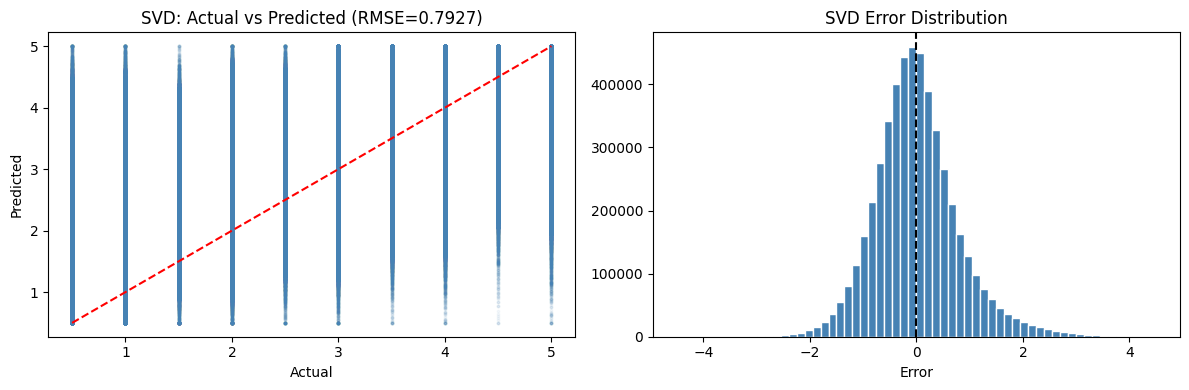

In [8]:
# Visualize

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_true, preds_svd_tuned, alpha=0.05, s=3, color="steelblue")
axes[0].plot([0.5, 5], [0.5, 5], "r--")
axes[0].set_title(f"SVD: Actual vs Predicted (RMSE={rmse_t:.4f})")
axes[0].set_xlabel("Actual"); axes[0].set_ylabel("Predicted")

axes[1].hist(preds_svd_tuned - y_true, bins=60, color="steelblue", edgecolor="white")
axes[1].axvline(0, color="black", ls="--")
axes[1].set_title("SVD Error Distribution")
axes[1].set_xlabel("Error")

plt.tight_layout()
plt.savefig(FIGURES_DIR + "svd_eval.png", dpi=150)
plt.show()

In [ ]:
# Save the model

joblib.dump({"model": svd_tuned, "preds": preds_svd_tuned, "results": svd_results},
            MODEL_DIR + "svd.joblib")
print("✅ SVD saved — move to 04_nmf.ipynb")

✅ SVD saved — move to 04_nmf.ipynb


: 